## Step 2: Exploratory Data Analysis (EDA) on Dataset

1. **Check ham vs. spam distribution**
2. **Create three new columns** from the input column:
   - `count_alphabet`
   - `count_words`
   - `count_sentence`
3. **Analyze the distribution** of these three new columns
4. **Find the most frequent words** in ham and spam texts

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv("../data/cleaned/cleaned.csv")
df.sample(5)

,target,text
2598,0,Go where n buy? Juz buy when we get there lar.
1665,0,Am watching house ÛÒ very entertaining ÛÒ am...
487,0,Got meh... When?
4529,0,I'm fine. Hope you are also
1219,0,"Not yet chikku..going to room nw, i'm in bus.."


In [71]:
# Checking ham and spam distribution
# ham -> 0
# spam -> 1
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

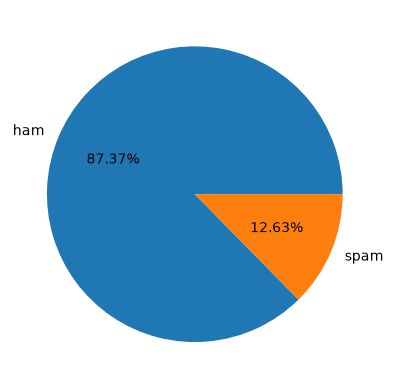

In [72]:
plt.pie(
  df["target"].value_counts(), 
  labels=["ham", "spam"],
  autopct="%1.2f%%"
)

### Adding count_alphabet column

In [73]:
df["count_alphabet"] = df["text"].apply(lambda x: len(x))

In [74]:
df.sample(3)

,target,text,count_alphabet
1568,0,Friends that u can stay on fb chat with,39
2849,0,"Oh, then your phone phoned me but it disconnected",49
106,0,How would my ip address test that considering ...,82


In [75]:
ham_avg_alp = df[df["target"] == 0]["count_alphabet"].mean()
spam_avg_alp = df[df["target"] == 1]["count_alphabet"].mean()

In [76]:
def bar_plot(category: list, values: list) -> None:
  bar = plt.bar(category, values)
  plt.bar_label(bar, label_type="center")
  plt.show()

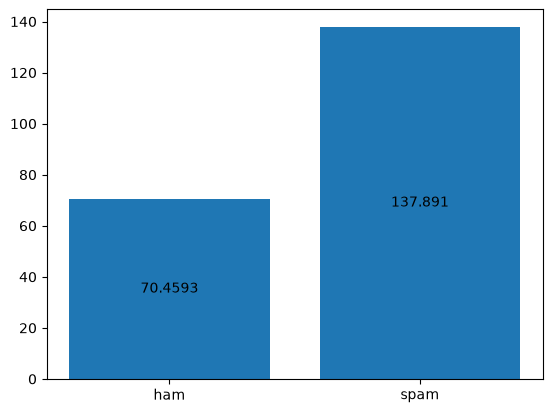

In [77]:
bar_plot(
  category= ["ham", "spam"],
  values= [ham_avg_alp, spam_avg_alp]
)

In [101]:
def plot_hist(column: str)-> None:
  sns.histplot(data=df, x=column, hue="target")
  plt.legend(title="Type", labels=["Spam", "Ham"])

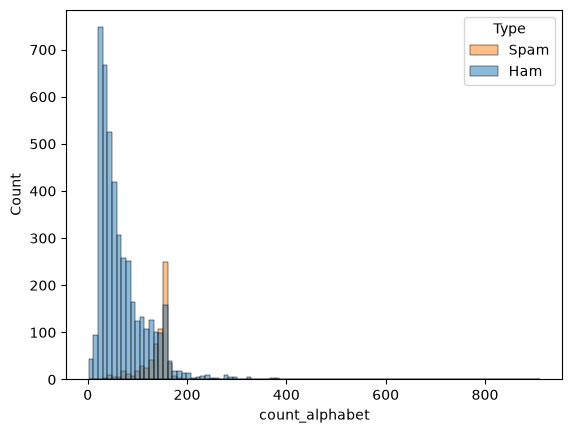

In [102]:
plot_hist(column= "count_alphabet")

### Adding count words column

In [78]:
import nltk
from nltk.tokenize import word_tokenize

In [79]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/omveersingh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/omveersingh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [80]:
df["count_words"] = df["text"].apply(lambda x: len(word_tokenize(x)))

In [81]:
df.sample(3)

,target,text,count_alphabet,count_words
134,0,I only haf msn. It's yijue@hotmail.com,38,10
1481,0,I think chennai well settled?,29,6
3856,1,HOT LIVE FANTASIES call now 08707500020 Just 2...,122,25


In [82]:
ham_avg_word = df[df["target"] == 0]["count_words"].mean()
spam_avg_word = df[df["target"] == 1]["count_words"].mean()

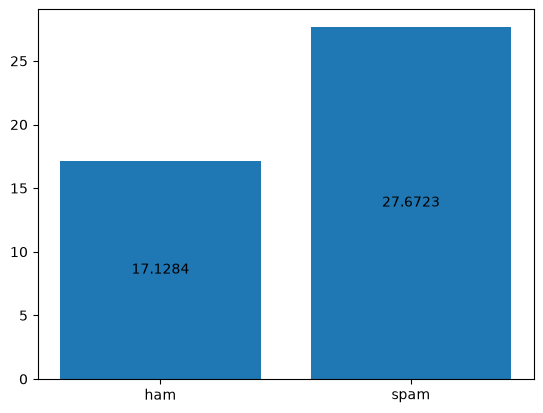

In [83]:
bar_plot(
  category=["ham", "spam"],
  values= [ham_avg_word, spam_avg_word]
)

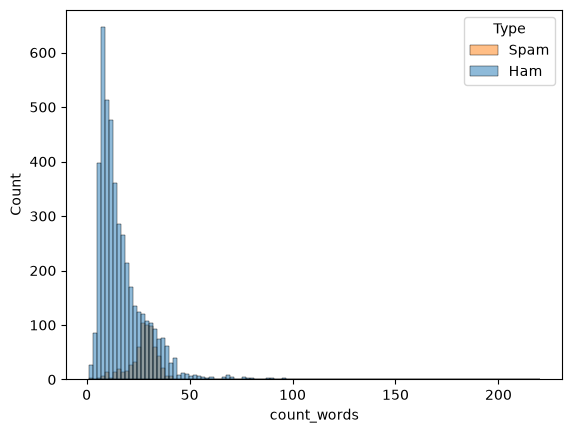

In [103]:
plot_hist(column= "count_words")

### Adding count_sentence column

In [84]:
from nltk.tokenize import sent_tokenize

In [85]:
df["count_sent"] = df["text"].apply(lambda x: len(sent_tokenize(x)))

In [86]:
df.sample(3)

,target,text,count_alphabet,count_words,count_sent
3211,0,Heehee that was so funny tho,28,6,1
106,0,How would my ip address test that considering ...,82,15,1
554,1,GENT! We are trying to contact you. Last weeke...,160,33,7


In [87]:
ham_avg_sent = df[df["target"] == 0]["count_sent"].mean()
spam_avg_sent = df[df["target"] == 1]["count_sent"].mean()

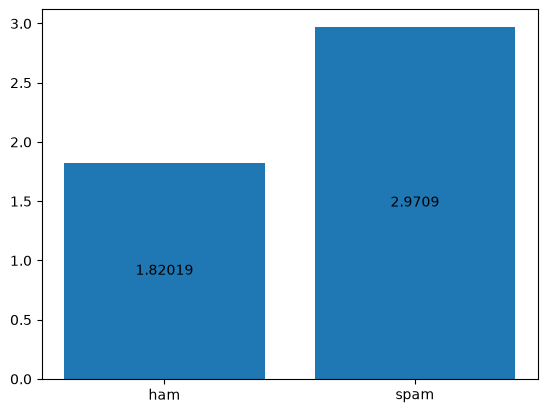

In [88]:
bar_plot(
  category= ["ham", "spam"],
  values=[ham_avg_sent, spam_avg_sent]
)

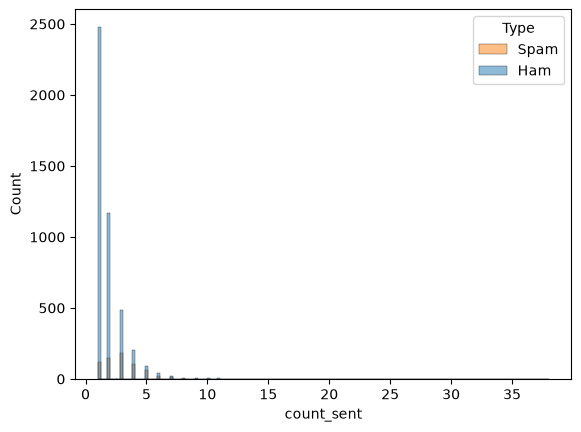

In [104]:
plot_hist(column= "count_sent")

### comparing all three columns at once

In [89]:
data = df[["target", "count_alphabet", "count_words", "count_sent"]].corr()
data

,target,count_alphabet,count_words,count_sent
target,1.000000,0.384717,0.262720,0.263939
count_alphabet,0.384717,1.000000,0.965686,0.624139
count_words,0.262720,0.965686,1.000000,0.679767
count_sent,0.263939,0.624139,0.679767,1.000000


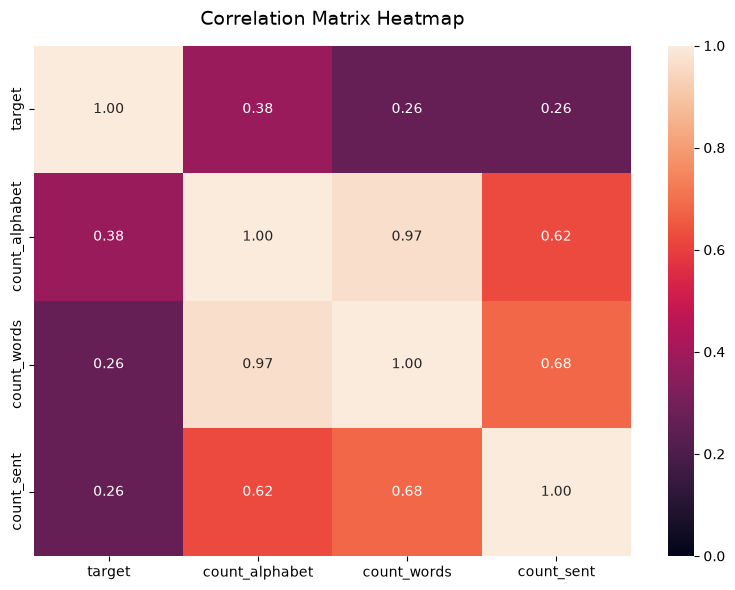

In [90]:
labels = ["target", "count_alphabet", "count_words", "count_sent"]

plt.figure(figsize=(8, 6))

sns.heatmap(data, annot=True, fmt=".2f",xticklabels=labels, yticklabels=labels,vmin=0, vmax=1)

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [105]:
df.to_csv("../data/cleaned/cleaned2.csv", index= False)